In [1]:
#библиотеки
import pandas as pd
import os
import csv
import re
from Bio import SeqIO
import copy
import matplotlib.pyplot as plt
from Bio import Entrez
from Bio.Blast import Applications
import os
from Bio.Blast.Applications import NcbiblastxCommandline
from textwrap import wrap
from scipy.signal import find_peaks


/opt/anaconda3/lib/python3.13/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [3]:
#функция для вытаскивания айдишников из файлов

def get_ids(filename):
    ids = []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                id_part = line.split(":")[0]
                ids.append(id_part)
    return ids



In [92]:
notannotCDS_ids = get_ids("Astroviridae_15102025_noannotCDS.txt")
notannotCDS_ids
notannotCDS_target_ids = get_ids("Astroviridae_15102025_noannot_targetCDS.txt")
notannotCDS_target_ids
diff = list(set(notannotCDS_target_ids) - set(notannotCDS_ids))
print(diff)

['MW347540', 'OQ709188', 'OQ709193', 'PQ421843', 'PX395425', 'PQ421852', 'PQ421853', 'PQ421845', 'PQ421842', 'MW645022', 'NC_040647', 'PQ421841', 'OM514376', 'PQ421846', 'PQ421848', 'MN841288', 'MW346737', 'PQ150499', 'MH188020', 'PP211223', 'KX290465', 'PX289196', 'OQ709191', 'OQ709190', 'MT568535', 'MZ182271', 'PQ421844', 'PQ421854', 'MZ443626', 'MW924357', 'MW924356', 'MZ182272', 'MW853972', 'MW645021', 'OQ802761', 'PQ421847', 'OQ709194', 'OQ709189', 'PX289197', 'OP413956', 'MW924358', 'PQ055527', 'PX289198', 'OQ709192', 'MZ291967', 'OP413950', 'PQ161557', 'ON932807']


In [47]:
#превращение tsv файла в csv 
def tsv_to_csv(tsv_path, csv_path):
    df = pd.read_csv(tsv_path, sep="\t")
    df.to_csv(csv_path, index=False)

In [ ]:
#добавление в файл id_prefix (айдишник генома)
def process_files(csv_files):
    result_rows = []
    for csv_file in csv_files:
        result_rows = []
        df = pd.read_csv(csv_file)
        df["ID белка"] = df["ID белка"].astype(str)
        mask1 = df["ID белка"].str.contains("_") & ~df["ID белка"].str.contains("\.")
        df.loc[mask1, "id_prefix"] = df.loc[mask1, "ID белка"].str.split("_").str[0]
        mask2 = df["ID белка"].str.contains(".") & ~df["ID белка"].str.contains("_")
        df.loc[mask2, "id_prefix"] = df.loc[mask2, "ID белка"].str.split(".").str[0]
        result_rows.append(df)
        result = pd.concat(result_rows, ignore_index=True)
        result.to_csv(csv_file, index=False)   
process_files(csv_files)

In [65]:
#скрипт для поиска ORFS
def find_ORFs(csv_files, csv_file_orf, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    orf_df = pd.read_csv(csv_file_orf, header=None).fillna('')
    orf_dict = orf_df.set_index(0)[1].to_dict()
    
    for csv_file in csv_files:
        df = pd.read_csv(csv_file)
        all_results = []

        for _, row in df.iterrows():
            description = str(row.get('Описание предсказания', ''))
            matched = False
            if description in orf_dict.keys():
                all_results.append({
                    'ID белка': row.get('ID белка', ''),
                    'Название семейства/белка': row.get('Название семейства/белка', ''),
                    'Описание предсказания': row.get('Описание предсказания', ''),
                    'Источник предсказания': row.get('Источник предсказания', ''),
                    'ORF': orf_dict[description],
                    'id_prefix': row.get('id_prefix', '')
                })
                matched = True

            if not matched:
                all_results.append({
                    'ID белка': row.get('ID белка', ''), 
                    'Название семейства/белка': row.get('Название семейства/белка', ''),
                    'Описание предсказания': row.get('Описание предсказания', ''),
                    'Источник предсказания': row.get('Источник предсказания', ''),
                    'Вхождение из orf': '-',
                    'ORF': '-',
                    'id_prefix': row.get('id_prefix', '')
                })

        results_df = pd.DataFrame(all_results)
        base_name = os.path.basename(csv_file).rsplit(".", 1)[0]
        output_file = os.path.join(output_dir, f"{base_name}_orf_results.csv")
        results_df.to_csv(output_file, index=False)
        print(f"Файл {csv_file} обработан -> {output_file}")


In [66]:
csv_files = ['interpro_выдача/actual_for_191125/output_interpro_new/not_annot_targetCDS_new.csv','interpro_выдача/actual_for_191125/output_interpro_new/not_annot_CDS_nucl_ORFs_merged_output.csv']
csv_file_orf = '../Domain_descriptions.tsv'
output_dir = 'interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try'
find_ORFs(csv_files,csv_file_orf, output_dir)

Файл interpro_выдача/actual_for_191125/output_interpro_new/not_annot_targetCDS_new.csv обработан -> interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_targetCDS_new_orf_results.csv
Файл interpro_выдача/actual_for_191125/output_interpro_new/not_annot_CDS_nucl_ORFs_merged_output.csv обработан -> interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_CDS_nucl_ORFs_merged_output_orf_results.csv


In [105]:
#Добавляем координаты в файл not_annot_CDS (координаты берем из фаста-файла, предсказанного get_orfs())
def add_orf_coords_from_get_orfs(csv_file, fasta_file, output_csv):
    id_to_coords = {}
    id_to_strand = {}

    with open(fasta_file, 'r', encoding='utf-8') as f:
        for line in f:
            if line.startswith('>'):
                m = re.match(r'^>(\S+).*?\[(\d+)\s*-\s*(\d+)\]', line)
                if m:
                    protein_id, start, end = m.groups()
                    coords = f"{start}-{end}"
                    id_to_coords.setdefault(protein_id, []).append(coords)
                    strand = "-" if "REVERSE SENSE" in line.upper() else "+"
                    id_to_strand[protein_id] = strand

    with open(csv_file, newline='', encoding='utf-8') as f_in, \
         open(output_csv, 'w', newline='', encoding='utf-8') as f_out:

        reader = csv.DictReader(f_in)
        fieldnames = reader.fieldnames + ['coords', 'strand']
        writer = csv.DictWriter(f_out, fieldnames=fieldnames)
        writer.writeheader()

        for row in reader:
            protein_id = row.get('ID белка', '')
            coords = ','.join(id_to_coords.get(protein_id, []))
            strand = id_to_strand.get(protein_id, '')
            row['coords'] = coords
            row['strand'] = strand
            writer.writerow(row)


In [106]:
add_orf_coords_from_get_orfs(
    csv_file='interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_CDS_nucl_ORFs_merged_output_orf_results.csv',
    fasta_file='interpro_input/not_annot_CDS_nucl_ORFs_after_getorfs.fasta',
    output_csv='interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_CDS_nucl_ORFs_merged_output_orf_result_coords.csv'
)

In [80]:
#Добавляем координаты в файл not_annot_target_CDS (координаты берем из genbank-файла)
def add_cds_coords_from_genbank(csv_file, genbank_file, output_file):
    cds_by_accession = {}

    for record in SeqIO.parse(genbank_file, "genbank"):
        if "accessions" in record.annotations:
            acc = record.annotations["accessions"][0]
        else:
            acc = record.id

        cds_list = []
        for feature in record.features:
            if feature.type == "CDS":
                start = int(feature.location.start) + 1   # GenBank: 0-based start
                end = int(feature.location.end)
                strand = "-" if "(-)" in str(feature.location) else "+"
                cds_list.append((f"{start}-{end}", strand))
        cds_by_accession[acc] = cds_list

    df = pd.read_csv(csv_file)
    def get_coords(raw):
        raw = str(raw).rstrip("|")
        if "." in raw:
            acc, idx = raw.split(".")
        else:
            acc, idx = raw, "1"
        try:
            idx = int(idx)
        except:
            idx = 1
        if acc in cds_by_accession and idx <= len(cds_by_accession[acc]):
            return pd.Series(cds_by_accession[acc][idx - 1])

        return pd.Series(["", ""])

    df[["coords", "strand"]] = df.iloc[:, 0].apply(get_coords)
    df.to_csv(output_file, index=False)



In [82]:
add_cds_coords_from_genbank(
    csv_file='interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_targetCDS_new_orf_results.csv',
    genbank_file="Astroviridae_15102025.gb",
    output_file="interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_targetCDS_new_orf_results_coords.csv"
)

In [117]:
#удаляем строки, где в поле ORFs прочерк
def remove_dash_orf(input_csv, output_csv):
    df = pd.read_csv(input_csv)
    df_clean = df[df['ORF'] != '-']
    df_clean.to_csv(output_csv, index=False)

In [121]:
remove_dash_orf(
    "interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_targetCDS_new_orf_results_coords.csv",
    "interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_targetCDS_final.csv"
)
remove_dash_orf(
    "interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_CDS_nucl_ORFs_merged_output_orf_result_coords.csv",
    "interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_CDS_final.csv"
)

In [173]:
#функция на анализ успешных находок и конфликтов 

def analyze_findings(csv_file, target_ids, output_file):
    valid_orf = {'1A', '1B', '2'}
    df = pd.read_csv(csv_file)

    res = {}
    other = []
    protein_info = {}

    for _, row in df.iterrows():
        orf_val = str(row["ORF"]).strip()
        if orf_val == '-':
            continue

        acc = row["id_prefix"]
        protein_info.setdefault(acc, [])
        protein_info[acc].append({
            "orf": orf_val,
            "coords": row["coords"],
            "strand": row["strand"],
            "ID белка": row.get("ID белка", "")
        })

        if orf_val not in valid_orf:
            other.append({
                "ac": acc,
                "orf": orf_val,
                "coords": row["coords"],
                "strand": row["strand"]
            })
            continue

        row_dict = {orf_val: [row["coords"], row["strand"]]}
        res.setdefault(acc, [])
        if row_dict not in res[acc]:
            res[acc].append(row_dict)

    acc_conflicts = []
    for acc, entries in res.items():
        seen_orf = {}
        seen_coords = {}
        for d in entries:
            (orf, coords) = list(d.items())[0]
            if orf in seen_orf or coords[0] in seen_coords:
                acc_conflicts.append(acc)
            seen_orf[orf] = True
            seen_coords[coords[0]] = True

    acc_conflicts = sorted(set(acc_conflicts))

    rows = []
    acc_successful = []
    for acc, ent in res.items():
        if acc not in acc_conflicts and acc in target_ids:
            acc_successful.append(acc)
            for orf_dict in ent:
                for orf, coord in orf_dict.items():
                    rows.append({
                        "ac": acc,
                        "orf": orf,
                        "Coord": coord[0],
                        "Strand": coord[1]
                    })

    successful_df = pd.DataFrame(rows)

    target_ids = set(target_ids)
    found_ids = set(res.keys())
    not_found = sorted(list(target_ids - found_ids))

    conflict_filtered = [x for x in acc_conflicts if x in target_ids]
    other_filtered = [x for x in other if x["ac"] in target_ids]

    with open(output_file, "w", encoding="utf-8") as f:
        f.write("Конфликтные:\n")
        for acc in conflict_filtered:
            f.write(f"{acc}\n")
            seen = set()
            for item in protein_info[acc]:
                key = (item['ID белка'], item['orf'], item['coords'], item['strand'])
                if key not in seen:
                    seen.add(key)
                    f.write(f"    ID белка={item['ID белка']}, orf={item['orf']}, coords={item['coords']}, strand={item['strand']}\n")

        f.write("\nУспешные:\n")
        for item in acc_successful:
            f.write(f"{item}\n")

        f.write("\nНе найденные:\n")
        for item in not_found:
            f.write(f"{item}\n")

        f.write("\nДругие:\n")
        for item in other_filtered:
            f.write(f"{item}\n")

    return successful_df



In [174]:
csv_file='interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_targetCDS_new_orf_results_coords.csv'
output_file= 'interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/findings_notannot_target_CDS.txt'
df_notannot_target_CDS = analyze_findings(csv_file,diff,output_file)

In [175]:
csv_file='interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/not_annot_CDS_nucl_ORFs_merged_output_orf_result_coords.csv'
output_file= 'interpro_выдача/actual_for_191125/predicted_orfs_after_interpro_new/second_try/findings_notannot_CDS.txt'
df_notannot_CDS = analyze_findings(csv_file, notannotCDS_ids, output_file)

In [195]:
def write_coords(csv_file, output_file, df):
    df_table = pd.read_csv(csv_file, sep=',', dtype=str)
    first_col = df_table.columns[0]
    df_table[first_col] = df_table[first_col].astype(str).str.strip()
    df['ac'] = df['ac'].astype(str).str.strip()
    for _, row in df.iterrows():
        ac = row['ac'].strip()          
        orf_col = row['orf'].strip()    
        coord = row['Coord'].strip()    
        strand = row.get('Strand', '+').strip()  
        mask = df_table[first_col] == ac
        if mask.any() and orf_col in df_table.columns:
            df_table.loc[mask, orf_col] = coord
            df_table.loc[mask, f'{orf_col}-strand'] = 1 if strand == '+' else -1
        else:
            pass
    df_table = df_table.fillna("NA")
    df_table.to_csv(output_file, index=False, sep=',', encoding='utf-8')
    

In [196]:
csv_file = 'Astroviridae_15102025_orf-coords.csv'
output_file_1 = 'Astroviridae_26112025_1_orf-coords.csv'
write_coords(csv_file, output_file_1, df_notannot_target_CDS)

In [197]:
output_file_2 = 'Astroviridae_26112025_orf-coords.csv'
write_coords(output_file_1, output_file_2, df_notannot_CDS)

In [257]:
#добавляем NA везде, где была пустая ячейка
df = pd.read_csv('Astroviridae_26112025_orf-coords.csv', dtype=str)
df =df.fillna("NA")
df.to_csv('Astroviridae_26112025_orf-coords_filled.csv', index=False, encoding='utf-8')

In [243]:
#скрипт для сравнения файлов с координатами, на выходе файл с различиями + список различающихся id
def compare_files(file1, file2, output_txt='comparison_coords.txt'):
    def read_lines(path):
        with open(path, "r", encoding="utf-8") as f:
            return {line.strip() for line in f if line.strip()}

    lines1 = read_lines(file1)
    lines2 = read_lines(file2)

    only_in_1 = sorted(lines1 - lines2)
    only_in_2 = sorted(lines2 - lines1)
    diff_ids = []
    with open(output_txt, 'w', encoding='utf-8') as f:
        for i in range(max(len(only_in_1), len(only_in_2))):
            x = only_in_1[i]
            x_id = x.split(',')[0]
            diff_ids.append(x_id)
            y = only_in_2[i]
            f.write(f"Строка в первом: {x}\n")
            f.write(f"Строка во втором: {y}\n\n")
    print(diff_ids)
            
file1 = 'Astroviridae_20112025_orf-coords.csv'
file2 = 'Astroviridae_26112025_orf-coords.csv'
compare_files(file1, file2)

['HUANSSPS', 'MH188020', 'MN034422', 'MN034849', 'MT568535', 'MW346737', 'MW347540', 'MW645021', 'MW645022', 'MW853972', 'MW924358', 'MZ182271', 'MZ182272', 'MZ291967', 'MZ443626', 'NC_040647', 'OM514376', 'OQ802761', 'PP211223', 'PQ055527', 'PQ161557', 'PQ421853']


In [245]:
#обрезка фаста-последовательности по координатам (на выходе три файла - 1A, 1B, 2)
def split_genome_and_reverse(input_file, coord_file):
    coord_df = pd.read_csv(coord_file, sep=",", index_col=0)
    orfs = ['1A', '1B', '2']
    dict_orfs = {}
    for orf in orfs:
        dict_orfs[orf] = list()
    seqs = SeqIO.parse(open(input_file), format='fasta')
    for seq in seqs:
        acc = seq.id.split("_")[0]
        if acc == 'NC' or acc == 'AC':
            acc = '_'.join([acc,seq.id.split("_")[1]])
        for orf in orfs:            
            if (acc in coord_df.index) and (coord_df.loc[acc,orf] != 'NA-NA'):
                cd = coord_df[orf][acc]
                s, e = [int(x) for x in cd.split('-')]
                seq_orf = copy.deepcopy(seq)
                seq_orf.seq = seq.seq[s:e]
                strand_col = f"{orf}-strand"
                if strand_col in coord_df.columns:
                    strand_value = coord_df.loc[acc, strand_col]
                    if strand_value == -1:
                        seq_orf.seq = seq_orf.seq.reverse_complement()
                        seq_orf.id += "_reverse"
                        seq_orf.description = seq_orf.id
                dict_orfs[orf].append(seq_orf)
    out_temp = os.path.splitext(input_file)[0]
    for orf in dict_orfs.keys():
        outfile = out_temp + '_' + orf + '.fasta'
        SeqIO.write(dict_orfs[orf], outfile, "fasta")

In [246]:
input_file = "Astroviridae_15102025.fasta"
coord_file = "Astroviridae_26112025_orf-coords.csv"
split_genome_and_reverse(input_file,coord_file)

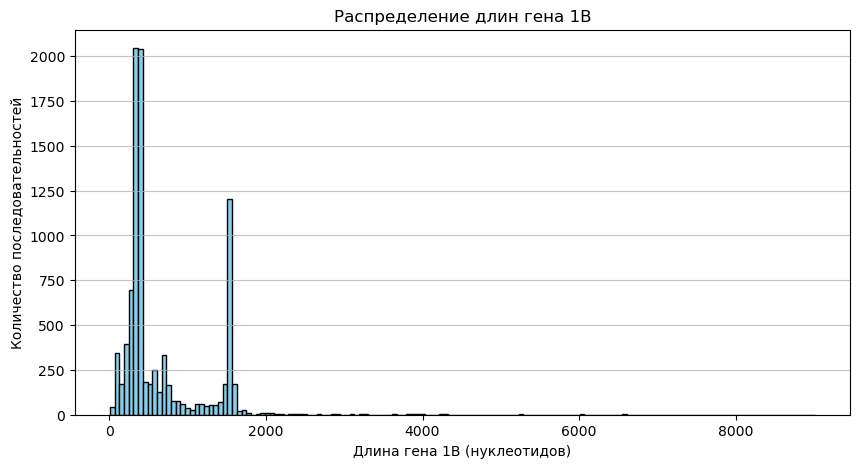

Пик около 339 нт, высота = 2045
Пик около 699 нт, высота = 335
Пик около 1538 нт, высота = 1205


In [33]:
#распределение длин 1B по координатам 
csv_file = 'Astroviridae_26112025_orf-coords.csv'
df = pd.read_csv(csv_file, dtype=str)
df['1B'] = df['1B'].astype(str).str.strip()
def get_length(coord):
    if coord in ["NA-NA", "NA", ""]:
        return None
    try:
        start, end = map(int, coord.split('-'))
        return abs(end - start) + 1
    except:
        return None
        
df['1B_length'] = df['1B'].apply(get_length)
lengths = df['1B_length'].dropna()
long_df = df.loc[df['1B_length'] > 4000, ['GBAC', '1B_length', '1B']].sort_values('1B_length', ascending=False)
counts, bin_edges = np.histogram(lengths, bins=150)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
peaks, properties = find_peaks(
    counts,
    prominence=20,
    distance=5
)

plt.figure(figsize=(10,5))
plt.hist(lengths, bins=150, color='skyblue', edgecolor='black')
plt.xlabel('Длина гена 1B (нуклеотидов)')
plt.ylabel('Количество последовательностей')
plt.title('Распределение длин гена 1B')
plt.grid(axis='y', alpha=0.75)
plt.show()

for p in peaks:
    print(f"Пик около {int(bin_centers[p])} нт, высота = {counts[p]}")


In [41]:
#отбор idшников выше какого-то лимита в csv и gb файл
gb_file = 'Astroviridae_15102025.gb'
long_ids = set(long_df['GBAC'].astype(str).str.strip())
definitions = {}
for record in SeqIO.parse(gb_file, "genbank"):
    rec_ids = {record.id}
    if "accessions" in record.annotations:
        rec_ids.update(record.annotations["accessions"])
    intersection = long_ids.intersection(rec_ids)
    if intersection:
        for rid in intersection:
            definitions[rid] = record.description
long_df['definition'] = long_df['GBAC'].map(definitions)
long_df.to_csv("1B_long_records_info.csv", index=False)
print(long_df.head())


          GBAC  1B_length        1B  \
1689  PP172843     9004.0   70-9073   
7587  MN033872     7207.0  838-8044   
1252  PQ055525     6595.0   29-6623   
1677  PP173657     6559.0   28-6586   
1250  PQ055527     6270.0   24-6293   

                                             definition  
1689  MAG: Ripikrak virus isolate KCAP1_k141_96123 g...  
7587  MAG: Astroviridae sp. isolate H3_Bulk_Litter_1...  
1252  MAG: Qianjiang astro-like virus 2 isolate QJ3T...  
1677  MAG: Ripistuv virus isolate MP3_k141_5253 geno...  
1250  MAG: Qianjiang astro-like virus 4 isolate QJ3T...  


In [255]:
Entrez.email = "adelina.kzn15@gmail.com"

for acc in ["PQ421852", "PQ421844"]:
    with Entrez.efetch(db="nuccore", id=acc, rettype="fasta", retmode="text") as handle:
        seq = handle.read()
    with open(f"{acc}.fasta", "w") as f:
        f.write(seq)

In [10]:
#ручная вставка координат
df = pd.read_csv("Astroviridae_26112025_orf-coords.csv",dtype=str)
key = "PX095815"
new_values = ["NA-NA", '' , "3080-4574", -1, "85-3082", -1]

df.loc[df['GBAC'] == key, df.columns[1:]] = [new_values]

df.to_csv("Astroviridae_26112025_orf-coords.csv", index=False)


In [85]:
long_df_new = []
for _, row in long_df.iterrows():
    if row['GBAC'] in ids:
        long_df_new.append(row)
long_df_new = pd.DataFrame(long_df_new)

In [86]:
ids = [
    "PP172843",
    "MN033872",
    #"PQ055525",
    "PP173657",
    #"PQ055527",
    #"PQ150499",
    #"MN841288",
    "MN035838",
    #"NC_040647",
    #"MH188020",
    #"MT585643",
    #"MF768270",
    #"HQ889774",
    #"MT585644",
    #"OQ802761",
    "PP172690",
    "OM451110",
    "AB308374",
    "NC_030922",
    "MZ546174",
    "MW863310",
    "FJ375759",
    "KC342249",
    "AB325804",
    "ON807348",
    #"MT568535",
    "MW346737",
    "OM451112",
    "OM451115",
    "OM451148",
    "OM451111",
    #"MZ443626",
    #"OR439362",
    #"PQ161557",
    #"OR270284",
    "PP871917",
    "OM451109",
    "OM451116",
    #"GU985458",
    "OM451113",
    "OM451114"
]

In [66]:
#скрипт для вытаскивания нуклеотидных последовательностей по айдишникам в фаста-файл 
def extract_to_fasta_nucl(filename, id_list, output_fasta):
    with open(output_fasta, "w") as out:
        for record in SeqIO.parse(filename, "genbank"):
            acc = record.name.split('.')[0]
            if acc not in id_list:
                continue
            definition = record.description
            nucl_seq = str(record.seq)
            header = f">{acc} | {definition}"
            out.write(header + "\n")
            for line in wrap(nucl_seq, 60):
                out.write(line + "\n")


In [67]:
extract_to_fasta_nucl('Astroviridae_15102025.gb', ids, 'long_orfs.fasta')

In [110]:
headers_file = "headers_only.txt"
out_file = "headers_annotated_fixed.txt"

def parse_coords(brackets):
    m = re.search(r"\[(\d+)\s*-\s*(\d+)\]", brackets)
    if m:
        return int(m.group(1)), int(m.group(2))
    return None, None

with open(headers_file) as fin, open(out_file, "w") as fout:
    for line in fin:
        line = line.strip()
        if not line:
            continue

        m = re.match(r">(.*?)_(\d+)", line)
        if not m:
            fout.write(line + "\n")
            continue

        gbac = m.group(1)             
        number = m.group(2)        
        header_id = f">{gbac}_{number}" 

        head_block = re.search(r"\[(\d+\s*-\s*\d+)\]", line)
        if head_block:
            coords_header = head_block.group(0)
            h1, h2 = parse_coords(coords_header)
            len_header = abs(h2 - h1) + 1
        else:
            coords_header = "NA"
            len_header = "NA"

        row = long_df[long_df["GBAC"] == gbac]
        if row.empty:
            coords_df = "NA"
            len_df = "NA"
            definition = "NA"
        else:
            row = row.iloc[0]
            coords_df = f"[{row['1B']}]"
            df1, df2 = parse_coords(coords_df)
            len_df = abs(df2 - df1) + 1
            definition = row["definition"]

        fout.write(f"{header_id} | {definition} | {coords_header} | {coords_df} | {len_header} | {len_df}\n")


In [83]:
#скрипт для фильтрации по длине 
def filter_fasta_by_length(
    input_fasta: str,
    output_fasta: str,
    min_len: int = 0,
    max_len: int | None = None
):
    with open(output_fasta, "w") as out:
        for record in SeqIO.parse(input_fasta, "fasta"):
            seq_len = len(record.seq)
            if seq_len >= min_len and (max_len is None or seq_len <= max_len):
                SeqIO.write(record, out, "fasta")

filter_fasta_by_length(
    input_fasta="Astroviridae_15102025_1B.fasta",
    output_fasta="Astroviridae_15102025_1B_filtered_2.fasta",
    min_len=1300
)

In [6]:
#подсчет последовательностей короче чем ___
def count_fasta_shorter_than(
    input_fasta: str,
    min_len: int
) -> int:
    count = 0
    for record in SeqIO.parse(input_fasta, "fasta"):
        if len(record.seq) > min_len:
            count += 1
    return count

n_short = count_fasta_shorter_than(
    input_fasta="Astroviridae_1B_filtered_less_amb.fasta",
    min_len=0
)
print(n_short)

1799


In [94]:
#-1 от начала 1b координат
#скрипт подходит только для прямых последовательностей (не reverse)
df = pd.read_csv("Astroviridae_26112025_orf-coords.csv",dtype=str)
l = [
    "OR248794"
]


for key in l:
    coords = df.loc[df['GBAC'] == key]
    b_coords = coords['1B'].iloc[0]
    start_1b = int(b_coords.split('-')[0])
    start_1b_new = start_1b+2
    end_1b = b_coords.split('-')[1]
    coords_new = str(start_1b_new) + '-'+ end_1b
    df.loc[df['GBAC'] == key, df.columns[3]] = [coords_new]
df.to_csv("Astroviridae_26112025_orf-coords.csv", index=False)


In [3]:
#-2 от начала 1b координат
#скрипт подходит только для прямых последовательностей (не reverse)
df = pd.read_csv("Astroviridae_26112025_orf-coords.csv",dtype=str)
l = [
    "OR270057"
]



for key in l:
    coords = df.loc[df['GBAC'] == key]
    b_coords = coords['1B'].iloc[0]
    start_1b_new = int(b_coords.split('-')[0])+1
    end_1b = b_coords.split('-')[1]
    coords_new = str(start_1b_new) + '-'+ end_1b
    df.loc[df['GBAC'] == key, df.columns[3]] = [coords_new]
df.to_csv("Astroviridae_26112025_orf-coords.csv", index=False)


In [1]:
#скрипт для удаления гэпов в ак-последовательностях
def remove_gaps_from_fasta(input_fasta, output_fasta):
    with open(input_fasta) as fin, open(output_fasta, "w") as fout:
        seq = []
        header = None
        for line in fin:
            line = line.strip()
            if line.startswith(">"):
                if header is not None:
                    fout.write(header + "\n")
                    fout.write("".join(seq).replace("-", "") + "\n")
                header = line
                seq = []
            else:
                seq.append(line)
        if header is not None:
            fout.write(header + "\n")
            fout.write("".join(seq).replace("-", "") + "\n")
remove_gaps_from_fasta('Astroviridae_1B_final_less_amb_aa.fasta', 'Astroviridae_1B_final.fasta')

In [37]:
#скрипт для удаления пустых последовательностей
def remove_empty_seqs(input_fasta, output_fasta):
    with open(input_fasta) as fin, open(output_fasta, "w") as fout:
        fl = 0
        seq = []
        header = None
        for line in fin:
            line = line.strip()
            if line.startswith(">"):
                if fl == 0:
                    fl = 1
                    if header is not None:
                        fout.write(header + "\n")
                        fout.write("".join(seq) + "\n")
                    header = line
                    seq = []
                elif fl == 1:
                    continue
            else:
                fl = 0
                seq.append(line)
        if header is not None:
            fout.write(header + "\n")
            fout.write("".join(seq) + "\n")
remove_empty_seqs('clustered_rep.fasta', 'clustered_rep_new.fasta')

In [134]:
# Подсчет количества последовательностей в FASTA-файле в Jupyter Notebook
def count_fasta_sequences(fasta_file):
    count = 0
    with open(fasta_file, 'r') as f:
        for line in f:
            if line.startswith('>'):
                count += 1
    return count


fasta_path = "clade_analysis/Mammalia.fasta"
total_sequences = count_fasta_sequences(fasta_path)
print(f"Количество последовательностей в файле: {total_sequences}")


Количество последовательностей в файле: 1008


In [24]:
file_with_names = "clusterRep_83.fasta"  # файл с заголовками, >названия
file_with_sequences = "Astroviridae_1B_filtered.fasta"  # файл с последовательностями
output_file = "Astroviridae_1B_filtered_nucl_83.fasta"  # куда сохраняем совпавшие последовательности

names_to_extract = set()
with open(file_with_names) as f:
    for record in SeqIO.parse(f, "fasta"):
        names_to_extract.add(record.id)
with open(output_file, "w") as out_f:
    for record in SeqIO.parse(file_with_sequences, "fasta"):
        if record.id in names_to_extract:
            SeqIO.write(record, out_f, "fasta")


In [30]:
#парсинг domtblout-файла
columns = [
    'gene_id',          # 'RdRP_1'
    'pfam',             # 'PF00680.26'
    'length',           # '450'
    'sequence_id',      # 'PV418557_NA_CaAstV-Dog-AUS-perth-6-2022_Canis-lupus-familiaris_2022'
    'strand',           # '-'
    'alignment_length', # '523'
    'evalue',           # '2.9e-44'
    'bit_score',        # '152.0'
    'identity',         # '0.1'
    'query_start',      # '1'
    'query_end',        # '1.1'  (проверить, может это смещение или ошибка)
    'subject_start',    # '1.5e-48' (тут похоже на evalue, стоит уточнить)
    'subject_end',      # '3.8e-44'
    'coverage',         # '151.6'
    'some_ratio',       # '0.1.1'
    'gaps',             # '11'
    'mismatches',       # '393'
    'q_len',            # '36'
    's_len',            # '429'
    'frame',            # '30'
    'alignment_identity', # '475'
    'score',            # '0.84'
    'category',         # 'Viral'
    'description_1',    # 'RNA-dependent'
    'description_2',    # 'RNA'
    'description_3'     # 'polymerase'
]


df = pd.read_csv(
    "pfam.domtblout",
    comment="#",
    sep=r"\s+",
    names=columns,
    engine="python",
    on_bad_lines="skip" 
)

df["combined"] = (
    df["category"].fillna("").astype(str)+
    df["description_1"].fillna("").astype(str) +
    df["description_2"].fillna("")+
    df["description_3"].fillna("")
)
new_df = df.loc[~df['gene_id'].str.contains("RdRP", na=False)]
new_df.to_csv("pfam_not_rdrp.csv", index=False)
ids=new_df['sequence_id']
unique_ids = ids.unique()
with open('unique_seq_ids.txt', 'w') as f:
    for seq_id in unique_ids:
        f.write(seq_id + '\n')


In [91]:
remove_list_file = "unique_seq_ids.txt"
input_fasta = "Astroviridae_1B_aa_83.fasta"
output_fasta = "Astroviridae_1B_aa_83_no_RdRp.fasta"

with open(remove_list_file) as f:
    remove_ids = set(line.strip() for line in f)

with open(output_fasta, "w") as out_f:
    for record in SeqIO.parse(input_fasta, "fasta"):
        if record.id not in remove_ids:
            SeqIO.write(record, out_f, "fasta")


In [92]:
len(unique_ids)

88

In [50]:
extract_taxa_id('Astroviridae_tree_new_07022026_new.nex', 'clusters_83.tsv', '#ff0000', 'Mammalia_ids.txt')

In [27]:
#поиск последовательностей, где нет host
df = pd.read_csv("Astroviridae_25012026_full.csv")
result = df[["ID", "Host", "class", "Isolate_x"]]
not_find = result[result["class"].isna()]
not_find_2 = not_find[not_find["Host"].isna()]
not_find_2 = not_find_2[['ID','Host', 'Isolate_x']].drop_duplicates()

not_find_2.to_csv("Astroviridae_25012026_full_without_host.csv", index=False)


In [28]:
#поиск последовательностей, где не нашлась lineage
df = pd.read_csv("Astroviridae_25012026_full.csv")
result = df[["ID", "Host", "class", "Isolate_x"]]
not_find = result[result["class"].isna()]
not_find = not_find[~not_find["Host"].isna()]
not_find["Host"] = not_find["Host"].str.split(";").str[0].str.strip()
not_find.loc[
    not_find["Host"].str.contains(r"\bHomo\s+sapiens\b", regex=True, na=False),
    "Host"
] = "Homo sapiens"
not_find_2 = (
    not_find
    .groupby("Host", as_index=False)["Isolate_x"]
    .apply(lambda x: "; ".join(sorted(set(x.dropna()))))
)
not_find_2['class'] = None

not_find_2.to_csv("Astroviridae_25012026_full_without_lineage.csv", index=False)


In [55]:
#отбор айдишников из fasta файла
input_fasta = "Astroviridae_1B_filtered_aa_83_rdrp.fasta"
output_txt = "ids_for_full_tree.txt"
ids = []
c = 0
with open(input_fasta, "r") as f:
    for line in f:
        if line.startswith(">"):
            if line[1:3] != 'NC':
                first_id = line[1:].strip().split("_")[0]
                ids.append(first_id)
            else:
                first_id = line[1:].strip().split("_")[0] + '_' + line[1:].strip().split("_")[1]
                ids.append(first_id)
            c+=1

with open(output_txt, "w") as f:
    for i in ids:
        f.write(i + "\n")
print(c)


336


In [54]:
df = pd.read_csv("Astroviridae_25012026_full.csv")
df_filtered = df[df["ID"].isin(ids)]
df_filtered.to_csv("Astroviridae_25012026_full_shorter.csv", index=False)

In [25]:
df_res =  pd.read_csv("Astroviridae_25012026_full.csv")
df_host =  pd.read_csv("Astroviridae_lineages.csv",  sep=";")
df_res = df_res.merge(
        df_host,
        how="left",
        left_on="Host",
        right_on="Host")
df_res["class"] = df_res["class_x"].fillna(df_res["class_y"])
df_res = df_res.drop(columns=["Isolate_y", 'class_x', 'class_y'])
df_res.to_csv("Astroviridae_25012026_full_2.csv", index=False)

In [29]:
#скрпит для замены файла с разделителем ; на ,
input_meta = "Astroviridae_25012026_full.csv"

output_meta = "Astroviridae_25012026_full.csv"

df = pd.read_csv(
    input_meta,
    sep=';',
    quotechar='"',
    dtype=str
)

df.to_csv(
    output_meta,
    index=False,
    sep=',',
    quoting=1 
)

✔ CSV файл успешно создан: Astroviridae_25012026_full.csv
Размер таблицы: (16012, 28)


In [106]:
from Bio import Phylo
# Читаем дерево в формате Newick
tree = Phylo.read("clade_analysis/Mammalia_align.nwk", "newick")

# Сохраняем в Nexus
Phylo.write(tree, "clade_analysis/Mammalia_align.nex", "nexus")

1

In [133]:
#анализ наличия рамок в списке геномов 
import pandas as pd

df = pd.read_csv("Astroviridae_26112025_orf-coords.csv")
input_txt = 'clade_analysis/Mammalia_ids.txt'

full_genome = 0
A_B_not_2 = 0
not_A_B_2 = 0
not_A_B_not_2 = 0

with open(input_txt, "r") as f:
    for i in f:
        acc = i.strip()
        s = df[df['GBAC'] == acc]
        #print(s)
        row = s.iloc[0]
        if row['1A'] == 'NA-NA' and row['2'] == 'NA-NA':
            not_A_B_not_2 += 1

        elif row['1A'] == 'NA-NA' and row['2'] != 'NA-NA':
            not_A_B_2 += 1

        elif row['1A'] != 'NA-NA' and row['2'] == 'NA-NA':
            A_B_not_2 += 1

        elif row['1A'] != 'NA-NA' and row['2'] != 'NA-NA':
            full_genome += 1

print("full_genome:", full_genome)
print("A_B_not_2:", A_B_not_2)
print("not_A_B_2:", not_A_B_2)
print("not_A_B_not_2:", not_A_B_not_2)


full_genome: 860
A_B_not_2: 58
not_A_B_2: 47
not_A_B_not_2: 43


In [131]:
df = pd.read_csv('MAV_wg_metadata.csv')
input_txt = 'clade_analysis/Other_ids.txt'
output_txt = 'diff_Other'
ids = df['GBAC'].to_list()
res_1 = []
for el in ids:
    new_el = el.split('/')[0]
    res_1.append(new_el)
res_2 = []
with open(input_txt, "r") as f:
    for i in f:
        acc = i.strip()
        res_2.append(acc)

diff  = set(res_1)  ^ set(res_2)

with open(output_txt, "w") as f:
    for i in diff:
        f.write(i + "\n")
print(diff)
print(len(diff))

{'PP871790', 'MW732155', 'OR367582', 'PV853945', 'PP871758', 'MN780842', 'MN464146', 'MG660832', 'OR448834', 'GQ502193', 'PV093024', 'PP871791', 'PQ423911', 'OM480542', 'JF327667', 'MK378539', 'ON482290', 'MW653748', 'KM401565', 'PP871753', 'MK386569', 'PQ510862', 'KY940545', 'AB740320', 'PQ583782', 'MK378508', 'ON792973', 'OR367598', 'PP871751', 'OQ968309', 'MZ819167', 'PV400866', 'OM105003', 'PV189390', 'OQ802742', 'PQ510856', 'PP871733', 'OK491635', 'PQ510865', 'OM451106', 'PV656460', 'MT766323', 'FJ375759', 'JN420359', 'MK378582', 'PP871785', 'MT766327', 'NC_033792', 'OR951068', 'PP871799', 'OQ198050', 'NC_023630', 'PP871787', 'KY855439', 'PP871797', 'LC047793', 'LC201595', 'KY271945', 'MK378559', 'OL695855', 'OR367593', 'OR220029', 'PP871741', 'MK327365', 'PP872098', 'MW732153', 'NC_023631', 'KT892966', 'PP871763', 'PP901928', 'OQ802715', 'MT766329', 'ON807320', 'PP871768', 'ON715001', 'ON049749', 'LC201597', 'OQ802721', 'PQ423913', 'PP968017', 'OR367603', 'MW863310', 'PP871740', 

In [132]:
df = pd.read_csv('MAV_wg_metadata.csv')
input_txt = 'Mammalia_ids.txt'
output_txt = 'diff_Mammalia'
ids = df['GBAC'].to_list()
res_1 = []
for el in ids:
    new_el = el.split('/')[0]
    res_1.append(new_el)
res_2 = []
with open(input_txt, "r") as f:
    for i in f:
        acc = i.strip()
        res_2.append(acc)

diff  = set(res_1)  ^  set(res_2)
with open(output_txt, "w") as f:
    for i in diff:
        f.write(i + "\n")
print(diff)
print(len(diff))

{'OQ968303', 'HQ916314', 'MT078248', 'OQ198039', 'MW732155', 'KT946727', 'OL695851', 'MK296753', 'LC694993', 'MW784095', 'MT832895', 'OQ198040', 'OQ198041', 'OR613297', 'MW653748', 'OR951021', 'LC695000', 'OR951095', 'OR951016', 'MN882005', 'KY940545', 'KJ495986', 'LC201613', 'MN882008', 'PP711873', 'KF233994', 'KT946735', 'MT451917', 'LC694988', 'OQ198033', 'ON792971', 'MW504552', 'FJ571067', 'ON624269', 'MK671312', 'OR951063', 'MT766323', 'OK107515', 'MK378521', 'LC047791', 'MW373714', 'OR951086', 'MN433703', 'MT766327', 'KX599350', 'MK987099', 'NC_033792', 'OP076766', 'OQ198050', 'KF374704', 'LC047793', 'LC201595', 'LC201603', 'LC732122', 'MW784092', 'MW504553', 'LC047800', 'ON624262', 'PP711880', 'OQ198038', 'LC201593', 'MW784109', 'OR951048', 'ON714999', 'OP432293', 'MW732153', 'ON595829', 'OL695857', 'JF713712', 'ON792970', 'MT766329', 'ON792968', 'MT906856', 'OP432300', 'LC201587', 'ON715001', 'ON624251', 'ON624281', 'OR613303', 'EU847149', 'OR951074', 'DQ028633', 'LC201597', 'O